In [ ]:
We'll focus on grouping **documents** — each document is one vector, and we want to find structure across the collection. Below are two main approaches:

In [43]:
import pandas as pd
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

We'll use the Consumer Financial Protection Bureau's [Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/). The code below will download the sample data with product columns == "Mortgage" or "Student loan"

In [44]:
# Load data (for public sharing) 
import os
import gdown

# Upload the data file to your Google Drive, and turn on the link sharing
# Replace 'YOUR_FILE_ID' with the actual file ID from your public Google Drive link e.g., "https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing"
file_id = '1VwrbAod_L2rdxw_LnWhS4ogQh_BChmum'

# Name for the downloaded file in Colab
output_filename = 'cfpb_sample.csv'

if file_id and not os.path.exists(output_filename):
    gdown.download(id=file_id, output=output_filename, quiet=False)
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Using existing file '{output_filename}'.")

# Now you can load it with pandas
cfpb= pd.read_csv(output_filename)
display(cfpb.head())


Using existing file 'cfpb_sample.csv'.


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2022-10-27,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,PNC received the first half of my biweekly pay...,NaN,PNC Bank N.A.,TX,75227,NaN,Consent provided,Web,2022-10-27,Closed with non-monetary relief,Yes,NaN,6138186
1,2015-07-21,Mortgage,Conventional adjustable mortgage (ARM),"Loan modification,collection,foreclosure",NaN,My home loan has been under a modification pro...,Company believes it acted appropriately as aut...,Ditech Financial LLC,TX,78840,NaN,Consent provided,Web,2015-07-21,Closed with explanation,Yes,No,1476551
2,2025-04-21,Student loan,Private student loan,Dealing with your lender or servicer,Problem with customer service,I have never been able to talk with a person a...,NaN,HEARTLAND PAYMENT SYSTEMS INC,NV,89512,NaN,Consent provided,Web,2025-04-21,Closed with explanation,Yes,NaN,13099896
3,2019-04-23,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Loan Number XXXX Property Address XXXX XXXX XX...,Company believes it acted appropriately as aut...,Mr. Cooper Group Inc.,VA,20147,Servicemember,Consent provided,Web,2019-04-23,Closed with explanation,Yes,NaN,3220071
4,2025-01-25,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Problem with customer service,PsIf/borrowers defense My student loans which ...,Company believes it acted appropriately as aut...,MOHELA,DE,199XX,NaN,Consent provided,Web,2025-01-25,Closed with explanation,Yes,NaN,11740340


In [45]:
# Cleaning and tokenization
import re
from spacy.lang.en.stop_words import STOP_WORDS
from string import punctuation

def preprocessing(text):
    stop_words = STOP_WORDS
    punc = set(punctuation) - {'.', '?', '!'}

    
    # 1) Lowercase
    text = text.lower()
    # 2) Remove redacted text (XX, XXXX)
    text = re.sub(r'\b[Xx]{2,}\b', '', text)
    # 3) Replace digit sequences with placeholder
    text = re.sub(r'\d+', 'DIGIT', text)
    # 4) Replace punctuation with spaces (so attached words split apart)
    text = "".join(ch if ch not in punc else ' ' for ch in text)
    # 5) Remove stop words (also removes extra spaces around them)
    text = ' '.join(w for w in text.split() if w not in stop_words)
    # 6) Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply and save to a new column
cfpb['text_clean'] = cfpb['Consumer complaint narrative'].map(preprocessing)
cfpb['text_clean'].head()

# Tokenize the cleaned text
nlp = spacy.load('en_core_web_sm', 
                 disable=['ner'])
cfpb['doc'] = list(nlp.pipe(cfpb['text_clean'], batch_size=100, n_process=6))
cfpb['tokens'] = cfpb['doc'].apply(lambda doc: [token.text for token in doc])
cfpb['lemmas'] = cfpb['doc'].apply(lambda doc: [token.lemma_ for token in doc])

## Describe the data

In [18]:
# download libraries
#!pip install scattertext
#!pip install wordcloud

### Descriptive Stats

In [47]:
# count number of characters
cfpb['complaint_len'] = cfpb['text_clean'].apply(len)

# count number of words
cfpb['word_count'] = cfpb['text_clean'].apply(lambda x: len(str(x).split()))

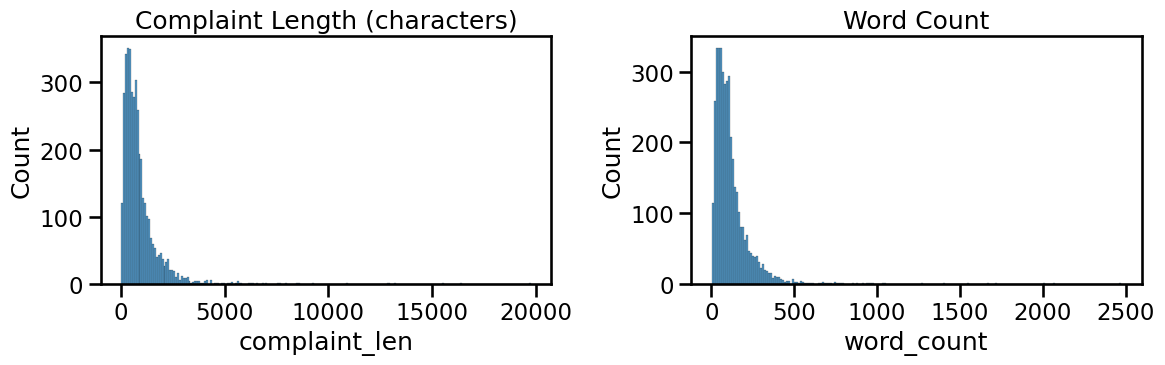

In [48]:
sns.set_context("talk")  # 옵션: "paper", "notebook"(기본), "talk", "poster"

# visualize the distributions of the count features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cfpb, x="complaint_len", ax=axes[0])
axes[0].set_title("Complaint Length (characters)")

sns.histplot(cfpb, x="word_count", ax=axes[1])
axes[1].set_title("Word Count")

plt.tight_layout()
plt.show()

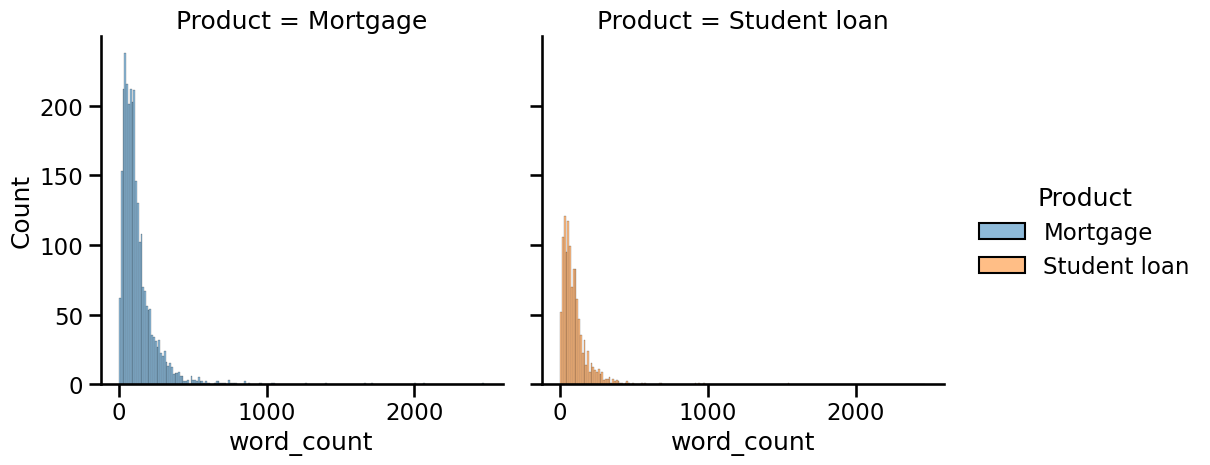

In [49]:
# histogram of word count by loan product 
sns.displot(cfpb,             # specify data
            x="word_count",   # x-axis feature
            hue = "Product",  # color by loan product
            col = "Product")  # color by loan product
plt.show()

### Word Cloud

A [wordcloud](https://github.com/amueller/word_cloud) is a quick visual summary of which words appear most often in a corpus — larger words are more frequent. It's useful as a first-pass exploratory tool to get a feel for dominant vocabulary. Below, we join all preprocessed tokens into a single string and pass it to `WordCloud.generate()`, which counts word frequencies internally and lays out the visualization.

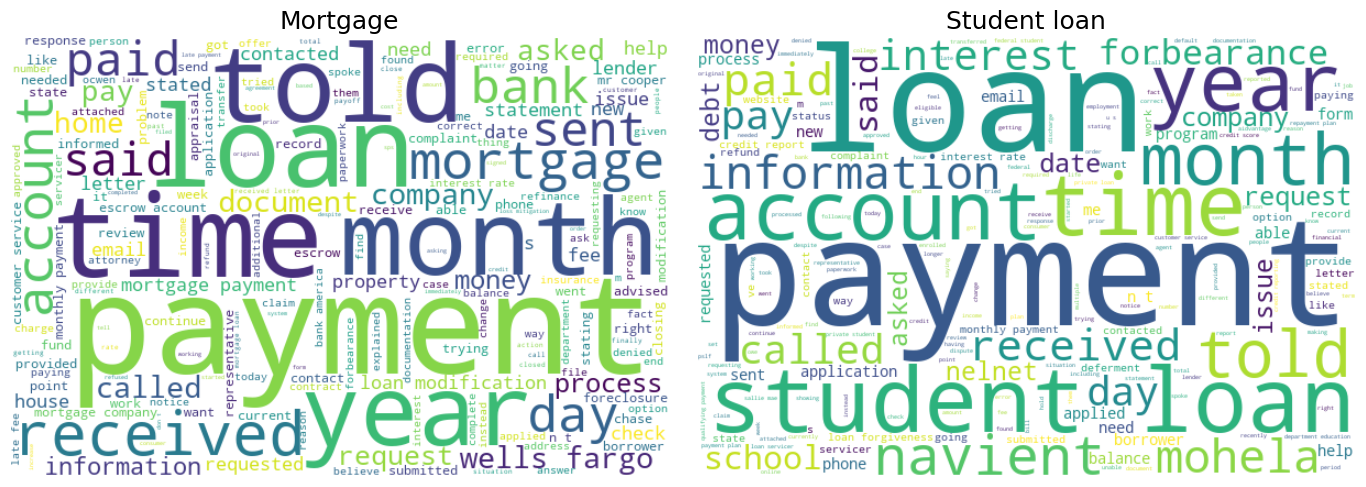

In [50]:
from wordcloud import WordCloud

# Build text for each product
mortgage_text = ' '.join(cfpb.loc[cfpb['Product'] == 'Mortgage', 'text_clean'])
student_text  = ' '.join(cfpb.loc[cfpb['Product'] == 'Student loan', 'text_clean'])

# Generate word clouds
wc_kwargs = dict(
    random_state=40,
    background_color='white',
    width=600,
    height=400,
    stopwords=['DIGIT'],
    # collocations=False,
)
wc_mortgage = WordCloud(**wc_kwargs).generate(mortgage_text)
wc_student  = WordCloud(**wc_kwargs).generate(student_text)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(wc_mortgage, interpolation='bilinear')
axes[0].set_title('Mortgage', fontsize=18)
axes[0].axis('off')

axes[1].imshow(wc_student, interpolation='bilinear')
axes[1].set_title('Student loan', fontsize=18)
axes[1].axis('off')

plt.tight_layout()
plt.show()



### ScatterText

[ScatterText](https://spacy.io/universe/project/scattertext) visualize how language differs among document types

In [51]:
cfpb['tokens'].head()

0    [pnc, received, half, biweekly, payment, secon...
1    [home, loan, modification, program, DIGIT, pre...
2    [able, talk, person, answer, calls, return, ca...
3    [loan, number, property, address, wv, nationst...
4    [psif, borrowers, defense, student, loans, dis...
Name: tokens, dtype: object

In [52]:
import scattertext as st
import spacy

# load reduced nlp + parsing first + batch process
corpus = st.CorpusFromParsedDocuments(
    cfpb,
    category_col='Product',
    parsed_col='doc', # spaCy doc objects from the previous tokenization step
).build()


# load default nlp + no parsing + single process 
# nlp = spacy.load('en_core_web_sm')

# corpus = st.CorpusFromPandas(
#     cfpb,
#     category_col='Product',
#     text_col='text_clean',  
#     nlp=nlp
# ).build()

In [53]:
html = st.produce_scattertext_explorer(corpus,
                                       category='Student loan',
                                       category_name='Student loan',
                                       not_category_name='Mortgage',
                                       width_in_pixels=1000,
                                       minimum_term_frequency=10,
                                       max_terms=4000,
                                    #    metadata=cfpb['Complaint ID']
                                    )
open("CFPB Sentiment.html", 'wb').write(html.encode('utf-8'))

5331959

# Unsupervised Methods for NLP

In the previous tutorial, we built numeric representations of text — from sparse bag-of-words to dense Word2Vec and contextual BERT embeddings. We also saw how to project those vectors into 2D for visualization:

- PCA   → linear, easy to interpret, captures global variance directions
- t-SNE → non-linear, great for revealing local clusters
- UMAP  → modern standard, fast, preserves both local and global structure

<img src='./images/fashion_mnist.png' alt="fashion" width="600">

(image from [here](https://www.kaggle.com/discussions/getting-started/120349))


These tools help us *see* the shape of the semantic space, but they don't tell us *where the groups are*. To actually identify groupings of documents, we turn to unsupervised algorithms. Below are two main approaches:

## 1. Clustering — "which documents belong together?"

Clustering algorithms partition documents into groups based on similarity in vector space. Each document ends up in (typically) one cluster.

- *K-means* — the classic baseline. Fast and intuitive, but you must choose `k` ahead of time.
- *Hierarchical clustering* — builds a tree of nested groupings (dendrogram). 
- *HDBSCAN* — a modern density-based method. No need to set `k`. 

**Note:** clustering can also be applied to *word* vectors (grouping semantically related words). We'll see word-level groupings re-emerge in the topic modeling section, where each topic is itself a cluster of related words.


## 2. Topic Modeling — "what themes run through this corpus?"

Topic models go a step further: instead of assigning each document to a single cluster, they treat documents as *mixtures of latent topics*, and each topic as a distribution over words.

- *LDA (Latent Dirichlet Allocation)* — the classic probabilistic topic model. Still widely cited in social-science papers; produces interpretable word lists per topic, but assumes bag-of-words input and can struggle with short texts.
- *BERTopic* — a modern alternative that runs sentence embeddings → UMAP → HDBSCAN → class-based TF-IDF. Captures semantic context that LDA misses, handles short documents well, and often produces cleaner topics out of the box.



Let's start by creating our tf-idf matrix again. 

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a tfidf vectorizer
vectorizer = TfidfVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

# Fit and transform on the complaint narratives
tf_dtm = vectorizer.fit_transform(cfpb['text_clean'])

# Create a tf-idf dataframe
tfidf = pd.DataFrame(tf_dtm.todense(),
                     columns=vectorizer.get_feature_names_out(),
                     index=cfpb.index)
tfidf.head()


,ab,abandoned,abandonment,abd,abide,abiding,ability,able,abnormal,abolish,...,youre,youth,youve,yr,yrs,zero,zillow,zip,zombie,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.277697,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.030286,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


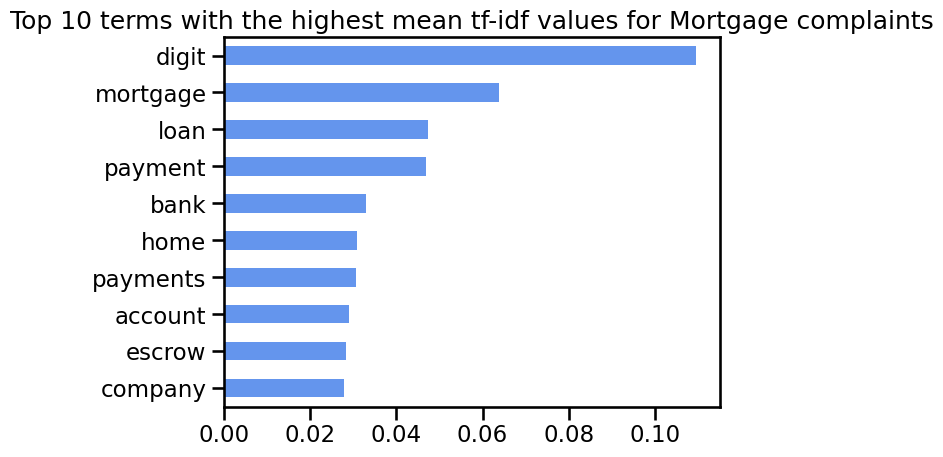

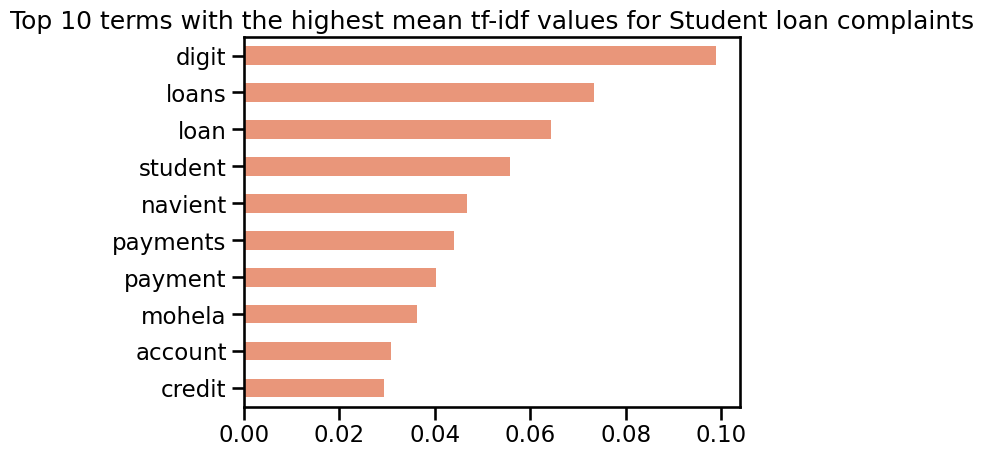

In [55]:
# Boolean masks for the two product categories
mortgage_index = cfpb[cfpb['Product'] == 'Mortgage'].index
student_index  = cfpb[cfpb['Product'] == 'Student loan'].index

# Mean tf-idf per token within each group
mortgage = tfidf.loc[mortgage_index].mean().sort_values(ascending=False).head(10)
student  = tfidf.loc[student_index].mean().sort_values(ascending=False).head(10)

# Plot top 10 terms with the highest mean tf-idf values for each product type
mortgage.plot(kind='barh',
              color='cornflowerblue',
              title='Top 10 terms with the highest mean tf-idf values for Mortgage complaints')
plt.gca().invert_yaxis()  # highest at the top
plt.show()

student.plot(kind='barh',
             color='darksalmon',
             title='Top 10 terms with the highest mean tf-idf values for Student loan complaints')
plt.gca().invert_yaxis()
plt.show()


### K-Means

Now let's implement a simple kmeans clustering algorithim and add those labels (which cluster each record belongs to) back to our dataframe.

In [65]:
from sklearn.cluster import KMeans

# Fit KMeans on the TF-IDF matrix
kmeans = KMeans(
    n_clusters=2,        # number of clusters
    max_iter=300,        # max iterations
    random_state=42      # reproducibility
).fit(tf_dtm)            # use the sparse matrix — more memory-efficient than the DataFrame

In [66]:
# Append cluster labels to the original DataFrame
cfpb['cluster'] = kmeans.labels_
cfpb['cluster'].value_counts().sort_index()


cluster
0     954
1    3116
Name: count, dtype: int64

In [67]:
# Cross-tabulate clusters with product categories
pd.crosstab(cfpb['cluster'], cfpb['Product'])


Product,Mortgage,Student loan
cluster,,
0,698,256
1,2186,930


/Users/young/.pixi/envs/base/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


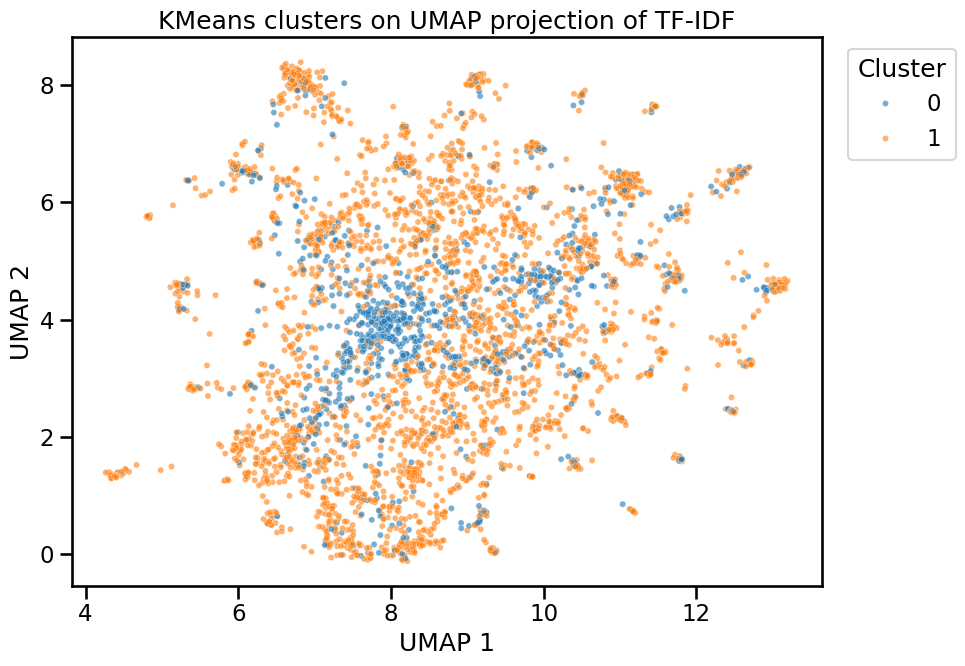

In [69]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Reduce TF-IDF matrix to 2D
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,    # 보통 5~50, 작을수록 local 구조 강조
    min_dist=0.1,      # 점들이 얼마나 뭉칠지 (0에 가까울수록 빽빽)
    metric='cosine'    # TF-IDF에는 cosine이 자연스러움
)
embedding = reducer.fit_transform(tf_dtm)

# 2) Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1],
    hue=cfpb['cluster'],
    palette='tab10',
    s=20,
    alpha=0.6
)
plt.title('KMeans clusters on UMAP projection of TF-IDF')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# 각 클러스터의 중심 벡터에서 가장 가중치 높은 단어 추출
terms = vectorizer.get_feature_names_out()
n_top_words = 10

for i in range(kmeans.n_clusters):
    top_indices = kmeans.cluster_centers_[i].argsort()[::-1][:n_top_words]
    top_words = [terms[idx] for idx in top_indices]
    print(f"Cluster {i}: {', '.join(top_words)}")

Cluster 0: digit, payment, loan, mortgage, escrow, payments, account, paid, pay, month
Cluster 1: digit, loan, mortgage, payment, payments, account, credit, bank, loans, company


#### Determining optiminal K: Elbow method

However, one of the key steps is to determine the optimal `k`. There are many ways to do this, but one approach is to iterate over a range of `k`s and use the elbow method to determine the best `k`.

The [elbow method](https://medium.com/@rohithramesh1991/unsupervised-text-clustering-using-natural-language-processing-nlp-1a8bc18b048d) will calculate the *within-sum of squared distances* of every point from its respective cluster, and this will serve as a measure of compactness. We want that number to be smaller. A steep drop in WSS will create an elbow and indicates the appropriate number of clusters. However, remember this is **not always guaranteed.**

Let's see how we can implement this:

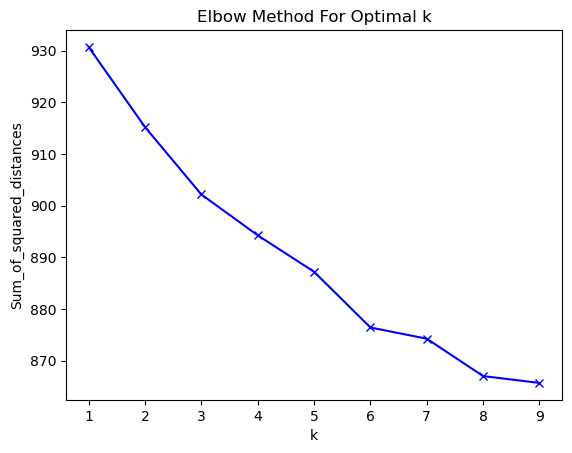

In [ ]:
#
# determining optional k: elbow method
# ------------------------------

# settings
# ---------
# set an empty list 
Sum_of_squared_distances = []

# set range of k
K = range(1, 10) # second number is the ceiling of the range, but remember it is exclusive


# loop over k
# ---------
for k in K:
    km = KMeans(n_clusters=k,     # number of clusters
                init='k-means++', # method for initalization 
                n_init=10)        # number of times the k-means algorithm is run with different centroid seeds
    km = km.fit(tfidf_matrix)     # fit
    Sum_of_squared_distances.append(km.inertia_) # pipe inertia calculations into list


# plot results
# ---------
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.xticks(range(1, max(K) + 1, 1))
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

#### Determining optiminal K: silhouette scores

Another way to determine the optimal `k` is to compare silhouette scores across clusters. Again, there are many ways to do this, but one approach is to iterate over a range of `k`s and compare how far the score for each cluster deviates from the average across clusters. Then select the `k` where each cluster has a value closest to the  average. 

[Silhouette scores](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) quantify how close each point in a cluster is to points in the neighboring clusters and thus provide a way to assess parameters like number of clusters visually. They silhouette score will take a value on a range from -1 to 1, where scores near +1 indicate that the sample is far away from the neighboring clusters, 0 indicates a sample is on or very close to the decision boundary between two neighboring clusters, and negative -1 indicates that sample might have been assigned to the wrong cluster.


In [ ]:
#
# determining optional k: silhouette scores
# ------------------------------
# define a number of functions

# iterate over a k-means fits to have different clusters
# ---------
def run_KMeans(max_k, data):
    max_k += 1
    kmeans_results = dict()
    for k in range(2 , max_k):
        kmeans = KMeans(n_clusters = k
                               , init = 'k-means++'
                               , n_init = 10
                               , random_state = 1)

        kmeans_results.update( {k : kmeans.fit(data)} )
        
    return kmeans_results


# calculate average silhouettes scores 
# ---------
# plot silhouettes scores
def printAvg(avg_dict):
    for avg in sorted(avg_dict.keys(), reverse=True):
        print("Avg: {}\tK:{}".format(avg.round(4), avg_dict[avg]))

# plot silhouettes scores       
def plotSilhouette(df, n_clusters, kmeans_labels, silhouette_avg): 
    fig, ax1 = plt.subplots(1)
    fig.set_size_inches(8, 6)
    ax1.set_xlim([-0.2, 1])   # play with this to set x-axis limits
    ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])
    
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--") # The vertical line for average silhouette score of all the values
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.title(("Silhouette analysis for K = %d" % n_clusters), fontsize=10, fontweight='bold')
    
    y_lower = 10
    sample_silhouette_values = silhouette_samples(df, kmeans_labels) # Compute the silhouette scores for each sample
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)) # Label the silhouette plots with their cluster numbers at the middle
        y_lower = y_upper + 10  # Compute the new y_lower for next plot. 10 for the 0 samples
    plt.show()
    
# put it altogether
def silhouette(kmeans_dict, df, plot=True):
    df = df.to_numpy()
    avg_dict = dict()
    for n_clusters, kmeans in kmeans_dict.items():      
        kmeans_labels = kmeans.predict(df)
        silhouette_avg = silhouette_score(df, kmeans_labels) # Average Score for all Samples
        avg_dict.update( {silhouette_avg : n_clusters} )
    
        if(plot): plotSilhouette(df, n_clusters, kmeans_labels, silhouette_avg)

**QUESTION:** What do we think about the fit? Are we happy with any set number of clusters?

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


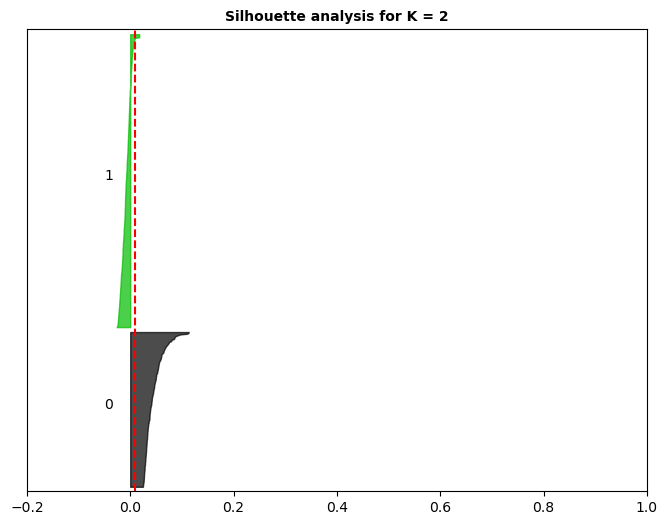

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


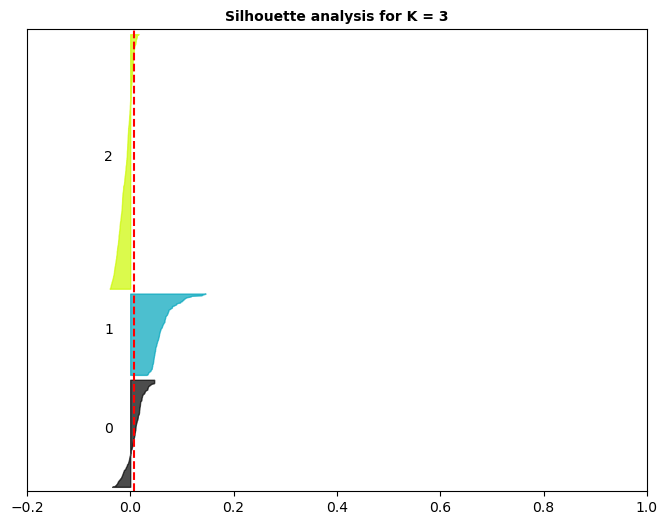

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


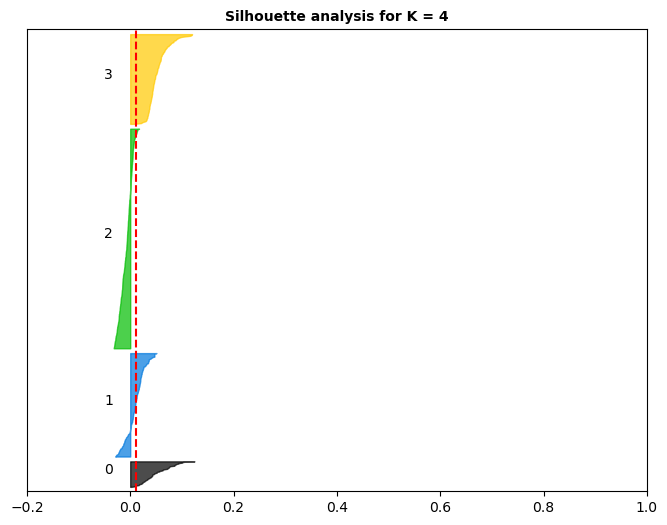

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


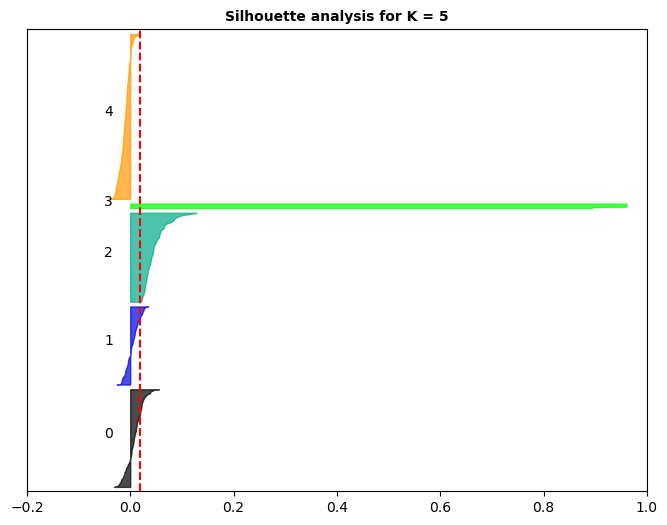

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


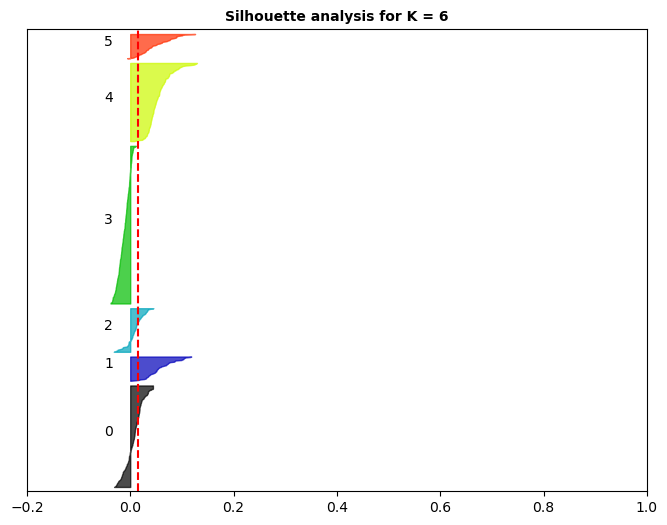

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


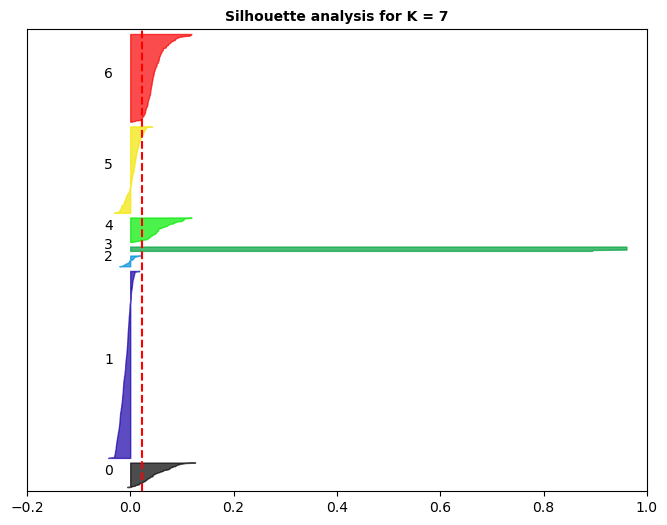

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


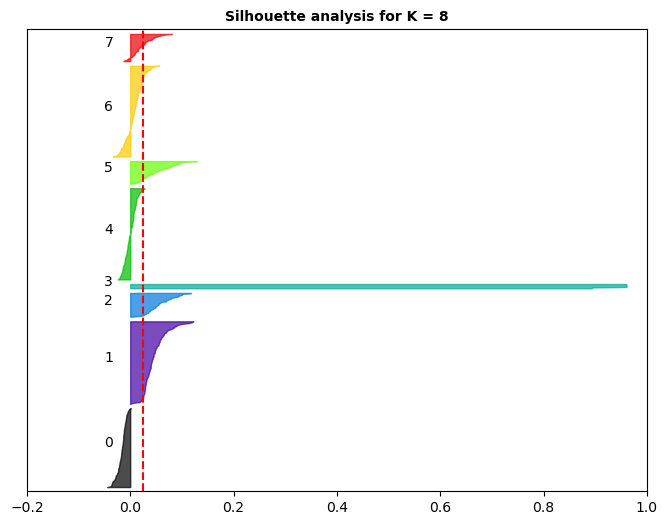

In [ ]:
#
# calculate silhouette scores across potential k-means clusters 
# ---------

# set K
k = 8 # choose 8 based on the elbow method result from above

# run the k-means algorithm
kmeans_results = run_KMeans(k,                # set k
                            data = tfidf_df)  # identify data


# plot the silhouette analysis
silhouette(kmeans_results,     # take k-means results
           tfidf_df)           # use the dataframe version

**ANSWER:**  Based on the results from the silhouette scores analysis, there does not seem to be an optimal number of clusters that fit the data well in their current form. A k-means clustering fit would likely perform better after more some more cleaning (removing more unhelpful words) or a rethinking of the dataset (perhaps there is no clear distinction between student loans and mortgage complaints using bag-of-word structured analysis. 

#### Cluster analysis of top words

Still, we might want to evaluate some of the top words in each cluster to confirm k-means is not a good approach here or to validate when it indeed is. We can write a function to iterate over the clusters and pull the top word. 

In [ ]:
#
# cluster analysis of top words in each cluster
# ------------------------------

# create functions
# ---------

# get the top features from each cluster
def get_top_features_cluster(tf_idf_array, prediction, n_feats):
    labels = np.unique(prediction)
    dfs = []
    for label in labels:
        id_temp = np.where(prediction==label) # indices for each cluster
        x_means = np.mean(tf_idf_array[id_temp], axis = 0) # returns average score across cluster
        sorted_means = np.argsort(x_means)[::-1][:n_feats] # indices with top 20 scores
        features = tf.get_feature_names_out()
        best_features = [(features[i], x_means[i]) for i in sorted_means]
        df = pd.DataFrame(best_features, columns = ['features', 'score'])
        dfs.append(df)
    return dfs

# plot them on a barplot
def plotWords(dfs, n_feats):
    plt.figure(figsize=(8, 4))
    for i in range(0, len(dfs)):
        plt.title(("Most Common Words in Cluster {}".format(i)), fontsize=10, fontweight='bold')
        sns.barplot(x = 'score' , y = 'features', orient = 'h' , data = dfs[i][:n_feats])
        plt.show()

**QUESTION:** Do these word plots give us any insight into why these k-means models are not performing well?

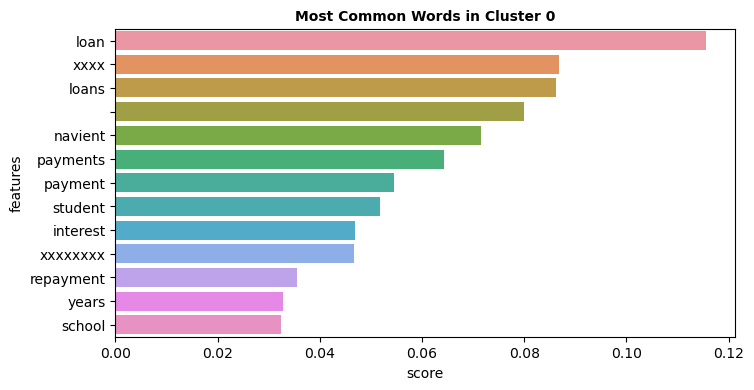

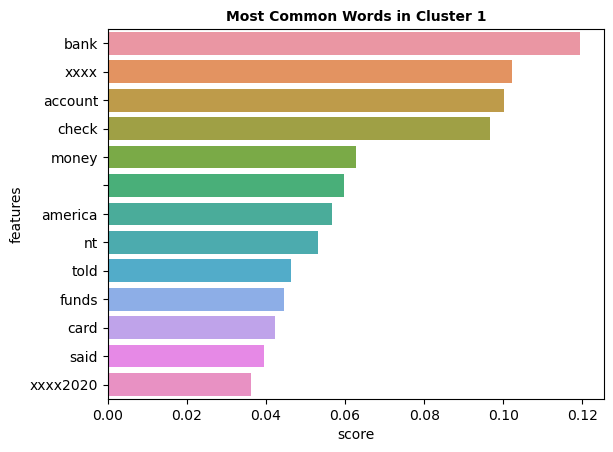

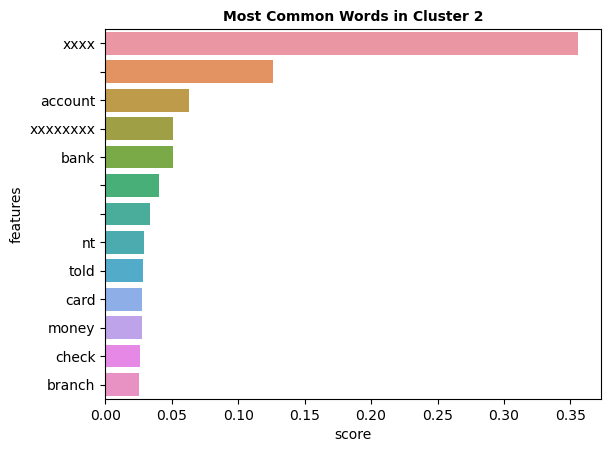

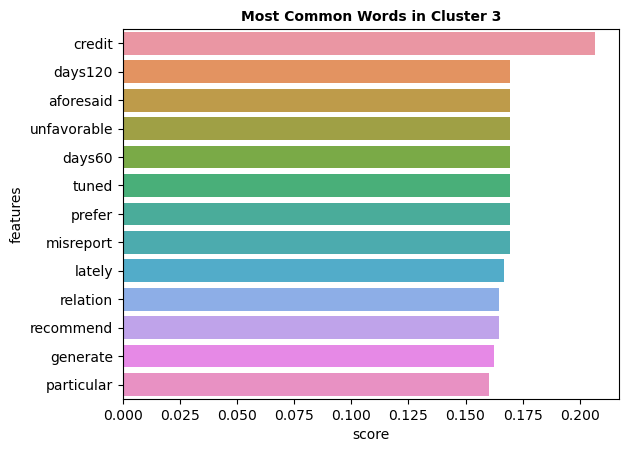

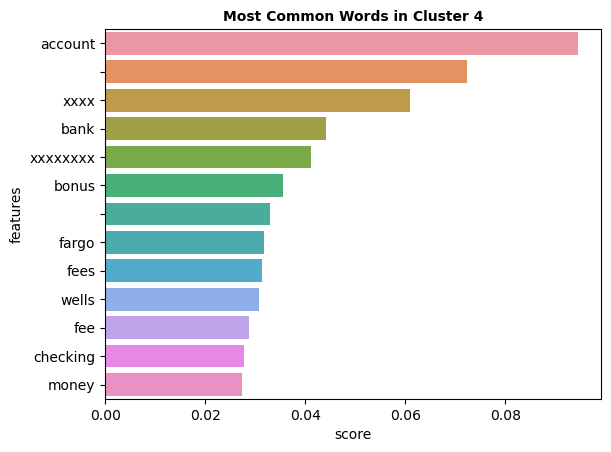

In [ ]:
# run k-means and visualize word count
# ---------

# get results from 5 clusters 
best_result = 5
kmeans = kmeans_results.get(best_result)

# processing for plot
tfidf_array = tfidf_df.to_numpy()     # convert dataframe to array
prediction = kmeans.predict(tfidf_df) # predict cluster using tf-idf dataframe


# plot
n_feats = 20
dfs = get_top_features_cluster(tfidf_array, # specify dataset which is an array
                               prediction,  # make specify prediciton
                               n_feats )    # set number of features 
plotWords(dfs, # specify data for plotting  
          13)  # set number of features

**ANSWER:** If we look back at the `tfidf_df`, we can see a number of paragraph separators (`\n`) that seem to remain in the documents, it is likely host black spaces that are showing up here, and would be one thing that might improve fit if we were to remove them. 

### Latent Dirichlet Allocation (LDA)


Now, let's turn to LDA. Remember, like other unsupervised machine learning models, topic models can help us uncover structure within a text. It does so through a "mixture model" - meaning every document is assumed to be "about" various topics, and we try to estimate the proportion each topic contributes to a document. 

Let that we have a tf-idf matrix, let's apply our LDA model. The key hyperparameter here is the `n_components` argument. Let's start with 5, and then print out our topics to see what we get.

In [ ]:
#
# Fitting a Latent Dirichlet Allocation model 
# ------------------------------

# initialize LDA model 
# ---------- 
lda = LatentDirichletAllocation(n_components=5,   # adjust the # of components
                                max_iter=20,      # adjust the # of iterations to fit model
                                random_state=0)   # set seed for reproducibility

# fit LDA to data
# ---------- 
lda = lda.fit(tfidf_matrix)  # use the sparse matrix created above 
lda

LatentDirichletAllocation(max_iter=20, n_components=5, random_state=0)

In [ ]:
# define a function to get and view top words for each topic
# ---------- 
def print_top_words(model, feature_names, n_top_words):    # define function and set parameters
    for topic_idx, topic in enumerate(model.components_):  # iterate over each topic 
        print("\nTopic #{}:".format(topic_idx))            # print topic index
        print(" ".join([feature_names[i]                   # print topics
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

In [ ]:
# get feature names from tf-idf matrices 
# ---------- 
tf_feature_names = tf.get_feature_names_out()

# apply function to print top words
print_top_words(lda,                # model 
                tf_feature_names,   # feature names 
                20)                 # number of top words


Topic #0:
xxxx1989 acccounts divided compromised 4x keybank disaster multiple science consistency amortization bribes trump natural rting nonlicensed loved vacated yrump xxxxpd

Topic #1:
forebearances immoral structuring misconduct accountwithout lousy corporations punish crooked officers decreased 1999 9r sson sensitive reconcile informationi bankin matteri reportson

Topic #2:
xxxx   account bank xxxxxxxx 

 loan money nt check told 
 loans payment card funds called received xxxx2020 payments

Topic #3:
ameritech courtesy acs deeper pod wrongfully 4600 pymt warnings wrongdoings alliant voted trial negatives amt certificates conduet thrown plunges dip

Topic #4:
credit lately relation days60 aforesaid misreport tuned prefer unfavorable days120 recommend generate particular seriously highly accordance greatly item present regulations



We have 5 topics! Some seem to be sensible (i.e. Topic #1 seems to be about banking attitudes while Topic #2 is about loans payments), but notice that the computer doesn't provide a "topic name" for us automatically, so there is still a role for humans to interpret and make sense of the output.

#### Topic weights

One thing we may want to do with the output is compare the prevalence of each topic across documents. A simple way to do this, is to merge the topic distribution back into the `pandas` dataframe.

Let's first get the topic distribution array.

In [ ]:
# calculate topic weights from distribution
# ----------
topic_dist = lda.transform(tfidf_matrix) # calculate distribution of topics for each document in the corpus 
topic_dist  # note that this output is an array

array([[0.02775814, 0.02775816, 0.88895863, 0.02775812, 0.02776695],
       [0.02771652, 0.02771655, 0.88902321, 0.02771649, 0.02782722],
       [0.03656152, 0.0365615 , 0.85351996, 0.03656152, 0.0367955 ],
       ...,
       [0.0212155 , 0.02121548, 0.9151342 , 0.02121541, 0.02121942],
       [0.022549  , 0.02254905, 0.90975659, 0.02254896, 0.0225964 ],
       [0.03473878, 0.03473879, 0.86095823, 0.03473877, 0.03482543]])

And then we'll merge back with original dataframe:

In [ ]:
# convert topic distribution array to pandas dataframe
# ----------
topic_dist_df = pd.DataFrame(topic_dist)

# join back to pandas dataframe and reset index
df_w_topics = topic_dist_df.join(cfpb.reset_index())

# view
df_w_topics.head() # notice that the topic distribution is the first 5 columns

,0,1,2,3,4,index,Date received,Product,Sub-product,Issue,...,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cluster
0,0.027758,0.027758,0.888959,0.027758,0.027767,99,05/16/20,Checking or savings account,Checking account,Managing an account,...,750XX,NaN,Consent provided,Web,05/16/20,Closed with explanation,Yes,NaN,3655341,0
1,0.027717,0.027717,0.889023,0.027716,0.027827,234,02/05/20,Checking or savings account,Checking account,Managing an account,...,658XX,Servicemember,Consent provided,Web,02/05/20,Closed with explanation,Yes,NaN,3521395,0
2,0.036562,0.036562,0.853520,0.036562,0.036795,332,04/11/20,Checking or savings account,Other banking product or service,Opening an account,...,331XX,NaN,Consent provided,Web,04/11/20,Closed with explanation,Yes,NaN,3602599,0
3,0.033611,0.033611,0.865517,0.033611,0.033650,346,04/01/20,Checking or savings account,Checking account,Opening an account,...,606XX,NaN,Consent provided,Web,04/01/20,Closed with explanation,Yes,NaN,3587986,0
4,0.022410,0.022410,0.910326,0.022410,0.022444,397,04/01/20,Student loan,Federal student loan servicing,Dealing with your lender or servicer,...,223XX,NaN,Consent provided,Web,04/01/20,Closed with explanation,Yes,NaN,3587932,1


Now we can check the average weight of each topic across loan product using `groupby`.

In [ ]:
# group by loan products and calculate mean
# ----------

# group the topds
grouped = df_w_topics.groupby('Product')

# loop over the dataframe and calculate mean
for i in range(0, 5):
    print(grouped[i].mean().sort_values(ascending=False))

Product
Checking or savings account    0.030542
Student loan                   0.029526
Name: 0, dtype: float64
Product
Checking or savings account    0.029730
Student loan                   0.028661
Name: 1, dtype: float64
Product
Checking or savings account    0.878848
Student loan                   0.849185
Name: 2, dtype: float64
Product
Student loan                   0.030433
Checking or savings account    0.029806
Name: 3, dtype: float64
Product
Student loan                   0.062195
Checking or savings account    0.031074
Name: 4, dtype: float64


None of the topics seem to have much separation, but let's visualize topics 2 and 3 to be sure.

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


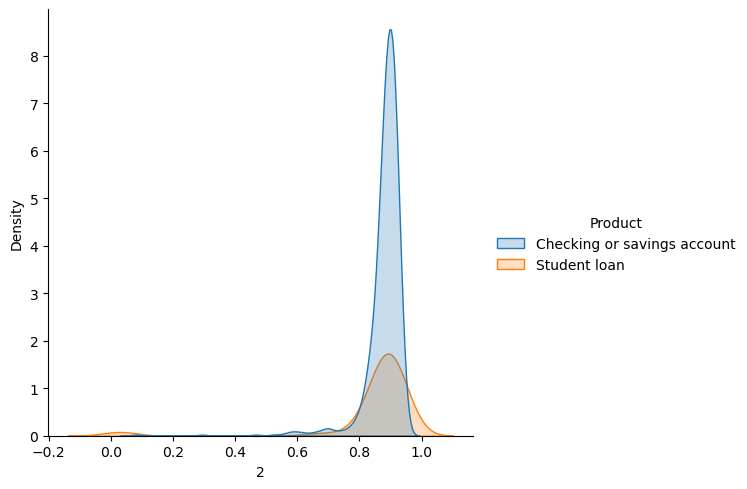

In [ ]:
# histogram of topic 2
# ----------
sns.displot(df_w_topics,      # data
            x=df_w_topics[2], # x-axis feature subet to only topic 2
            hue = "Product",  # by loan product
            kind = 'kde',     # specify kdensity plot
            fill = 'true')    # fill
plt.show()

/Users/Dora/anaconda3/envs/CSS2/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


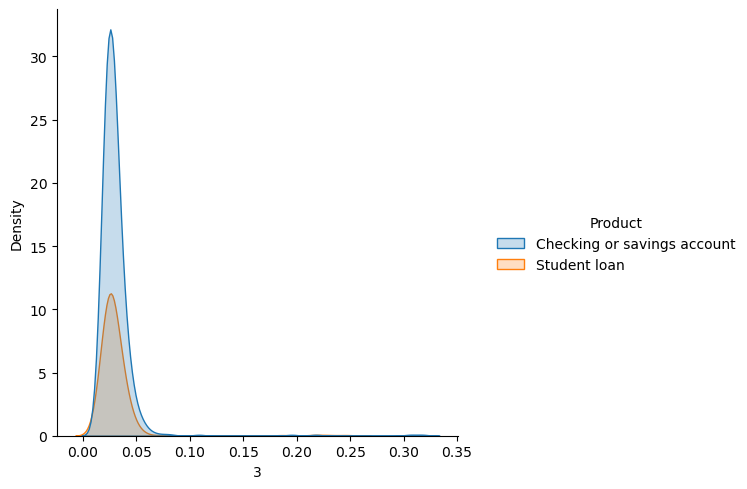

In [ ]:
# histogram of topic 3
# ----------
sns.displot(df_w_topics,      # data
            x=df_w_topics[3], # x-axis feature subet to only topic 2
            hue = "Product",  # by loan product
            kind = 'kde',     # specify kdensity plot
            fill = 'true')    # fill
plt.show()

Unsurprisingly, there doesn't seem to be very much separation between the two topics given that we didn't see much separation between the means above.

### Challenge

Try retraining the LDA with a different number of topics, for example, try 10. 


**QUESTION:** What do you notice? How is this similar to issues we've seen with other clustering algorithms?

In [ ]:
# LDA - 10 topics instead
# ---------- 

# initialize LDA model 
lda = LatentDirichletAllocation(n_components=10,  # specify 10 components
                                max_iter=20,      # set max iter to 20
                                random_state=0)   # set random seed

# fit LDA to data
lda = lda.fit(tfidf_matrix) # specify a matrix input

# define a function to get and view top words for each topic
def print_top_words(model, feature_names, n_top_words):   # define function and parameters
    for topic_idx, topic in enumerate(model.components_): # iterate over each topic 
        print("\nTopic #{}:".format(topic_idx))           # print topic index
        print(" ".join([feature_names[i]                  # print topics
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

# get feature names from tf-idf matrices 
tf_feature_names = tf.get_feature_names_out()

# apply function to print top 20 words
print_top_words(lda,                # model 
                tf_feature_names,   # feature names 
                20)                 # number of top words


Topic #0:
cd 600000 5600000 divided courtesy ncslt sites hesaa standing 4x ombudsmen renewed keybank levy pod disclosures letting doe congressman applications

Topic #1:
paypal td stopping 53 venmo tap inept gift videos supporting movement phony 350000 17 rid vendor slot 700 venue 1700000

Topic #2:
xxxx   account bank xxxxxxxx 

 loan money nt check told 
 loans payment card funds called received xxxx2020 time

Topic #3:
sallie mae credit recommend aforesaid days60 days120 unfavorable tuned prefer misreport highly lately relation greatly obtain generate particular seriously accordance

Topic #4:
bonus requirements promotion requirement 1500000 promotional td promo ally record support market wf advertised 000 reward package 37000 certain indicating

Topic #5:
wage ohio payed associates garnishment delta warning tracking cares 3500 47000 language screenshot automatic marketing inc incomedriven 32000 000 u

Topic #6:
acccounts paypal compromised flier path 99000 popular ate machine atmd

**ANSWER**: The topics produced are very sensitive to our choice of `n`. This is similar to the problem with finding the right number of clusters in other unsupervised learning problems, like k-means.

---
Notebook developed by Aniket Kesari. Modified by Prashant Sharma (2023) and annotated by Kasey Zapatka (2024).